In [4]:
import warnings
warnings.filterwarnings("ignore")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 130, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_2                │ (None, 130, 13)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_masking_2 (TimeMasking)    │ (None, 130, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frequency_masking_2             │ (None, 130, 13)        │             0 │
│ (FrequencyMasking)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 130, 256)       │       208,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 130, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,633 (1.49 MB)

 Trainable params: 389,633 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6781 - loss: 0.6365 - precision: 0.7220 - recall: 0.8957Val EER: 0.2500
Val min-tDCF: 0.7015
133/133 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.7020 - loss: 0.6034 - precision: 0.7325 - recall: 0.9231 - val_accuracy: 0.7200 - val_loss: 0.5226 - val_precision: 0.7200 - val_recall: 1.0000 - val_eer: 0.2500 - val_min_tdcf: 0.7015
Epoch 2/30
132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7324 - loss: 0.5464 - precision: 0.7581 - recall: 0.9217Val EER: 0.1182
Val min-tDCF: 0.3526
133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.7666 - loss: 0.4843 - precision: 0.7960 - recall: 0.9087 - val_accuracy: 0.8430 - val_loss: 0.3201 - val_precision: 0.8400 - val_recall: 0.9658 - val_eer: 0.1182 - val_min_tdcf: 0.3526
Epoch 3/30
132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8362 - loss: 0.3588 - precision: 0.8869 - recall: 0.8845Val EER: 0.0642
Val min-tDCF: 0.1860
133/133 ━━━━━━━━━━━━━━━━━━━━ 24

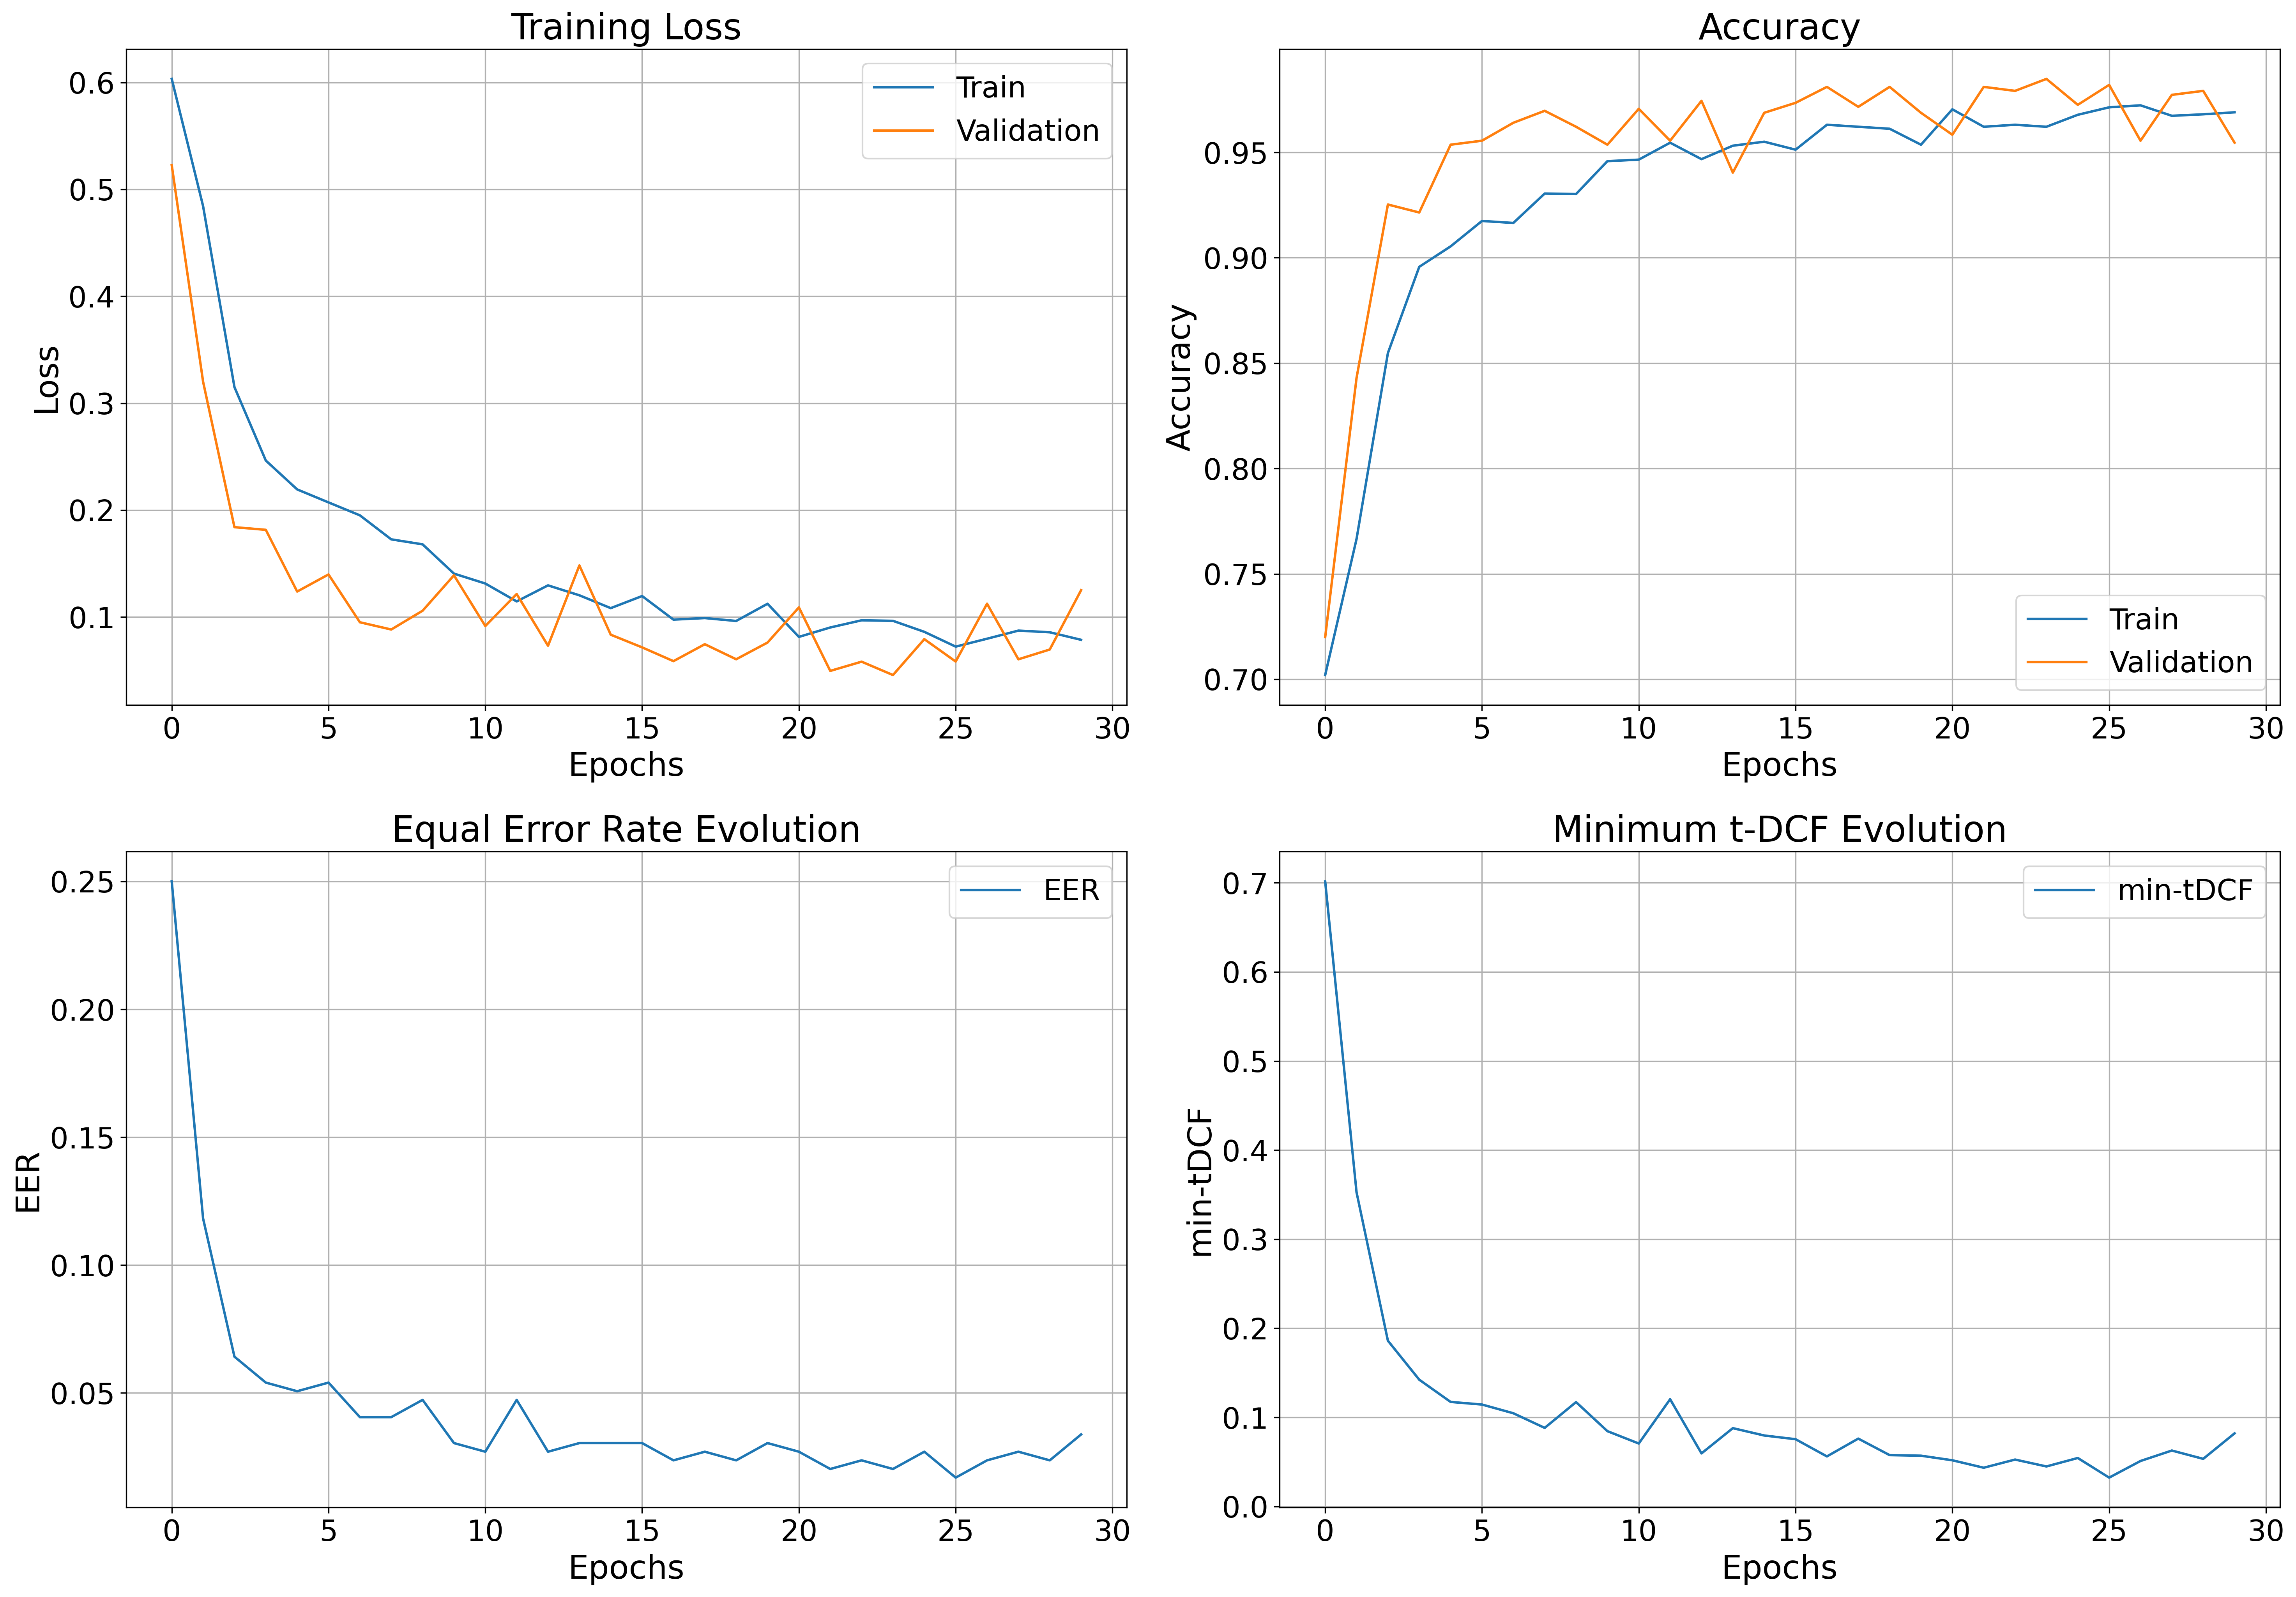

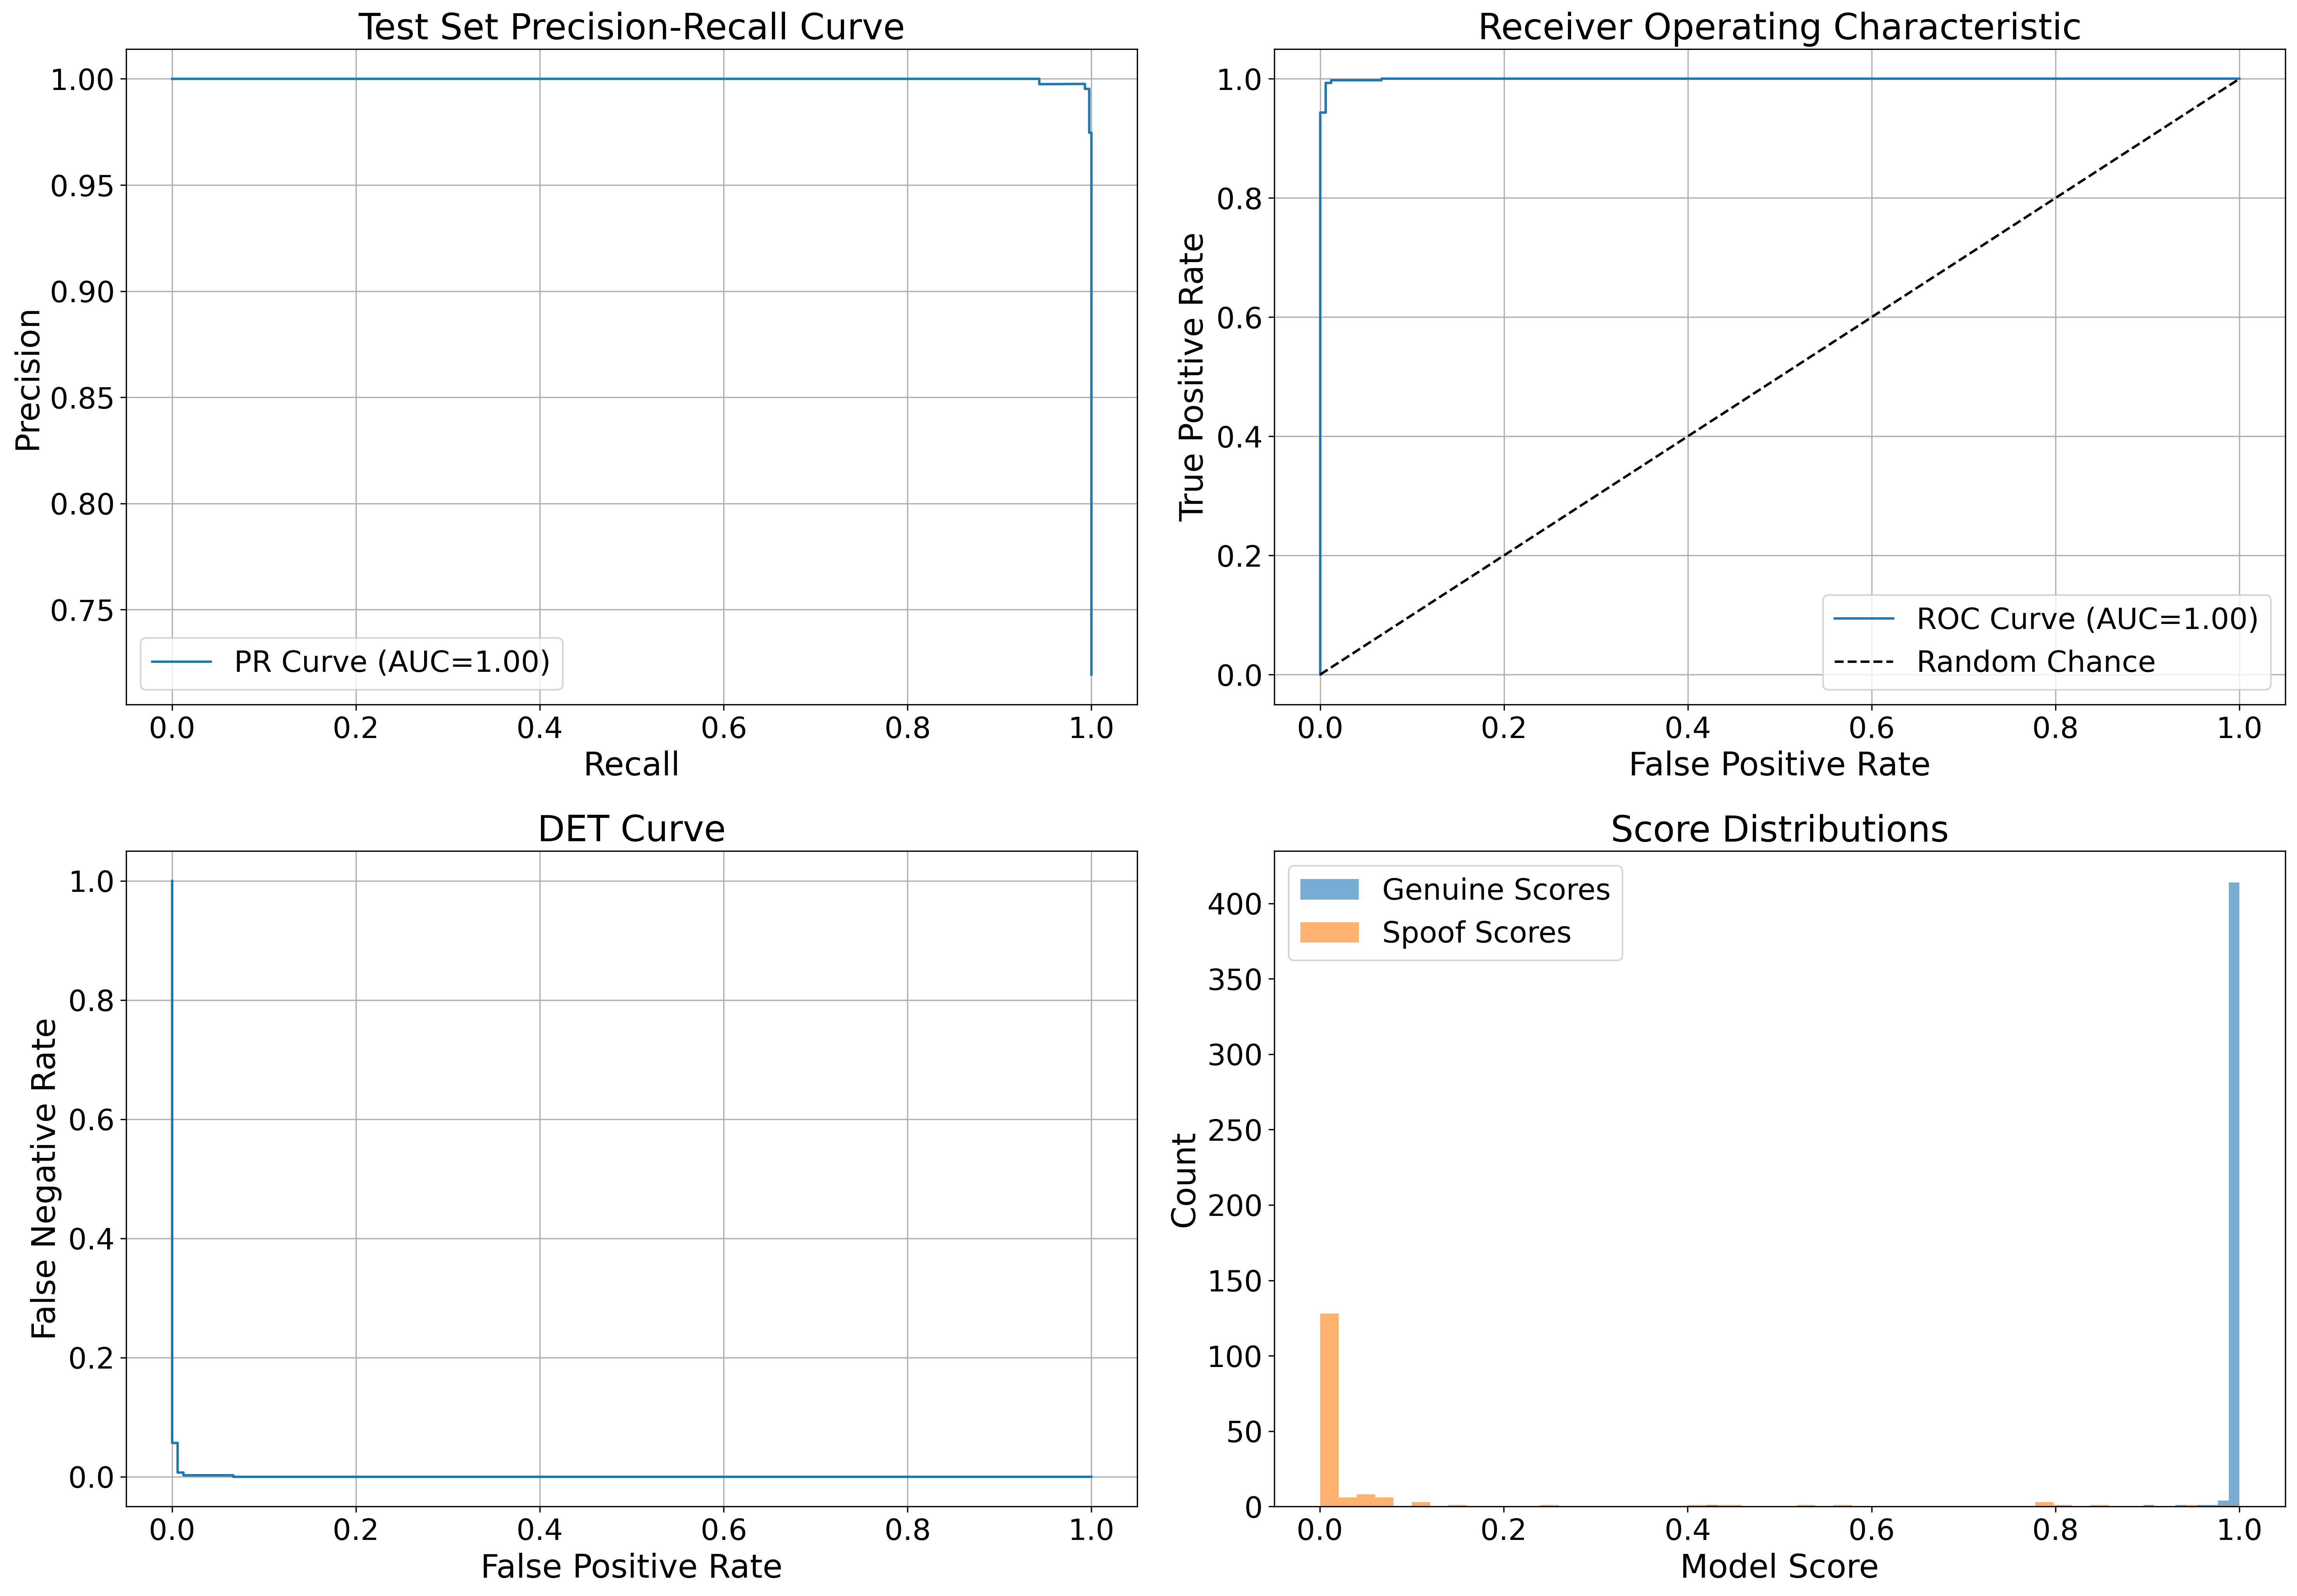

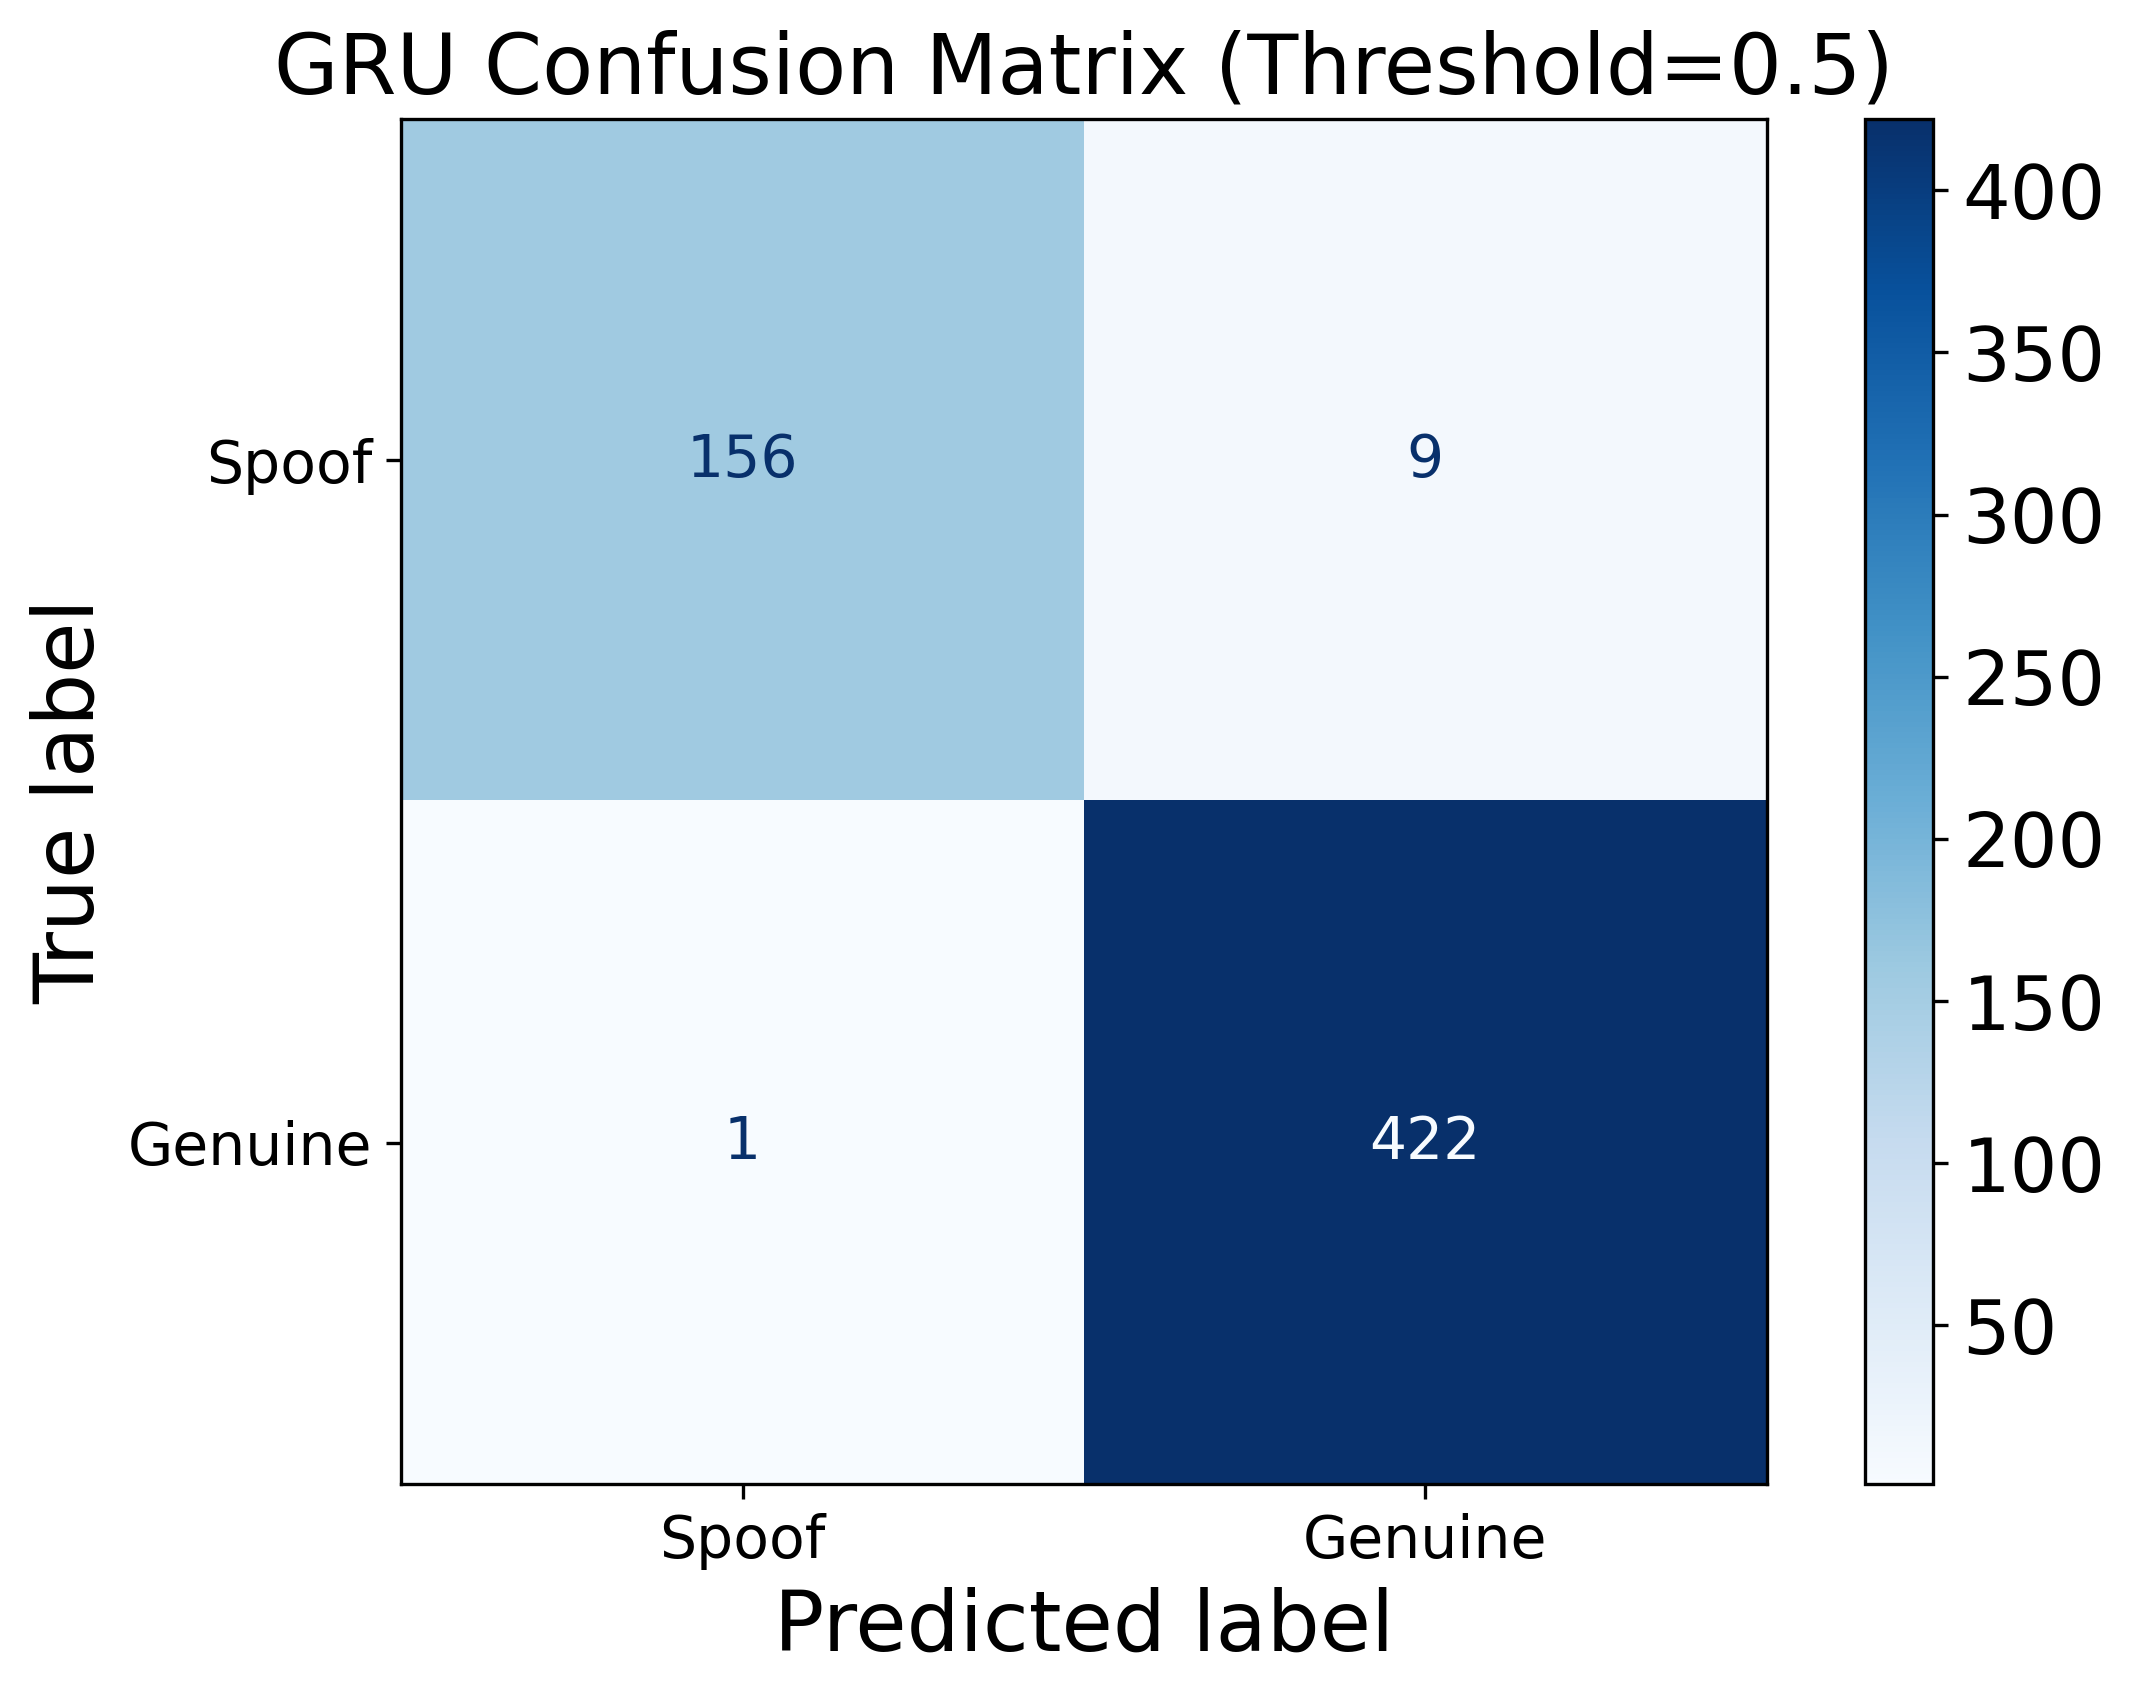


=== ASVspoof 2019 Challenge Metrics ===
Equal Error Rate (EER): 0.0061
Minimum Normalized t-DCF: 0.0067

=== Operational Metrics (Threshold=0.5) ===
Accuracy: 0.9830
Precision: 0.9791
Recall: 0.9976
F1-Score: 0.9883

Classification Report:
              precision    recall  f1-score   support

       Spoof       0.99      0.95      0.97       165
     Genuine       0.98      1.00      0.99       423

    accuracy                           0.98       588
   macro avg       0.99      0.97      0.98       588
weighted avg       0.98      0.98      0.98       588


Model saved successfully!


In [5]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, precision_recall_curve, auc,
                            confusion_matrix, ConfusionMatrixDisplay,
                            classification_report, accuracy_score)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ==============================================================
# 0. Configuration & Reproducibility
# ==============================================================
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Official ASVspoof 2019 Challenge Parameters
ASV_PARAMS = {
    'Pmiss_asv': 0.01, 'Pfa_asv': 0.001, 'Pmiss_spoof_asv': 0.05,
    'Cmiss_asv': 1, 'Cfa_asv': 1, 'Cmiss_cm': 1, 'Cfa_cm': 10,
    'pi_tar': 0.9405, 'pi_non': 0.0095, 'pi_spoof': 0.05
}

# ==============================================================
# Mask-Compatible Augmentation Layers
# ==============================================================
class TimeMasking(tf.keras.layers.Layer):
    def __init__(self, max_mask_length=10):
        super().__init__()
        self.max_mask_length = max_mask_length
        self.supports_masking = True  # Enable mask propagation

    def call(self, inputs, training=None):
        if not training:
            return inputs

        def _apply_time_mask(input_slice):
            time_steps = tf.shape(input_slice)[0]
            features = tf.shape(input_slice)[1]

            T = tf.random.uniform(shape=[], maxval=self.max_mask_length, dtype=tf.int32)
            T = tf.minimum(T, time_steps)
            t0 = tf.random.uniform(shape=[], maxval=time_steps - T, dtype=tf.int32)

            # Create 2D mask with broadcasting
            mask = tf.ones((time_steps, 1), dtype=tf.float32)
            time_mask = tf.pad(
                tf.zeros((T, 1), dtype=tf.float32),
                [[t0, time_steps - t0 - T], [0, 0]],
                constant_values=1
            )
            return input_slice * time_mask

        return tf.map_fn(_apply_time_mask, inputs)

    def compute_mask(self, inputs, mask=None):
        return mask  # Pass through original mask

class FrequencyMasking(tf.keras.layers.Layer):
    def __init__(self, max_mask_length=5):
        super().__init__()
        self.max_mask_length = max_mask_length
        self.supports_masking = True  # Enable mask propagation

    def call(self, inputs, training=None):
        if not training:
            return inputs

        def _apply_frequency_mask(input_slice):
            time_steps = tf.shape(input_slice)[0]
            features = tf.shape(input_slice)[1]

            F = tf.random.uniform(shape=[], maxval=self.max_mask_length, dtype=tf.int32)
            F = tf.minimum(F, features)
            f0 = tf.random.uniform(shape=[], maxval=features - F, dtype=tf.int32)

            # Create 2D mask with broadcasting
            freq_mask = tf.pad(
                tf.zeros((1, F), dtype=tf.float32),
                [[0, 0], [f0, features - f0 - F]],
                constant_values=1
            )
            return input_slice * freq_mask

        return tf.map_fn(_apply_frequency_mask, inputs)

    def compute_mask(self, inputs, mask=None):
        return mask  # Pass through original mask

# ==============================================================
# 1. Data Preparation
# ==============================================================
def load_data(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    X = np.array(data["mfcc"])[..., np.newaxis]
    X = np.squeeze(X)
    y = np.array(data["labels"])
    return X, y

X, y = load_data("preprocessed_mfcc_data1.json")


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=SEED
)

# ==============================================================
# 2. Augmented Model Architecture
# ==============================================================
def build_model(input_shape):
    model = models.Sequential([
        # Masking layer to skip time steps with zero values
        layers.Masking(mask_value=0., input_shape=input_shape),
        # Add Gaussian noise for regularization
        layers.GaussianNoise(stddev=0.01),
        # Custom time and frequency masking layers (if defined)
        TimeMasking(max_mask_length=10),
        FrequencyMasking(max_mask_length=5),
        # First GRU layer returning sequences for stacking
        layers.GRU(256, return_sequences=True),
        layers.Dropout(0.3),
        # Second GRU layer returning the last output
        layers.GRU(128),
        layers.Dropout(0.3),
        # Dense layers for classification
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model(X_train.shape[1:])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
model.summary()

# ==============================================================
# 3. ASVspoof-Compliant Metrics Callbacks (Unchanged)
# ==============================================================
class EERCallback(callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.eers = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0).ravel()
        fpr, tpr, _ = roc_curve(self.y_val, y_pred)
        fnr = 1 - tpr
        eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
        self.eers.append(eer)
        logs["val_eer"] = eer
        print(f"Val EER: {eer:.4f}")

class TDCFCallback(callbacks.Callback):
    def __init__(self, validation_data, **params):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.C1 = (params['pi_tar'] * (params['Cmiss_cm'] - params['Cmiss_asv'] * params['Pmiss_asv'])
                 - params['pi_non'] * params['Cfa_asv'] * params['Pfa_asv'])
        self.C2 = params['Cfa_cm'] * params['pi_spoof'] * (1 - params['Pmiss_spoof_asv'])
        self.min_C = min(self.C1, self.C2)
        self.min_tdcfs = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0).ravel()
        fpr, tpr, thresholds = roc_curve(self.y_val, y_pred)
        fnr = 1 - tpr
        min_tdcf = min((self.C1 * (1 - tpr[i]) + self.C2 * fpr[i]) / self.min_C
                      for i in range(len(thresholds)))
        self.min_tdcfs.append(min_tdcf)
        logs["val_min_tdcf"] = min_tdcf
        print(f"Val min-tDCF: {min_tdcf:.4f}")

# Callbacks setup
eer_callback = EERCallback((X_val, y_val))
tdcf_callback = TDCFCallback((X_val, y_val), **ASV_PARAMS)

metrics_callbacks = [
    eer_callback,
    tdcf_callback,
    callbacks.EarlyStopping(
        monitor='val_min_tdcf',
        patience=5,
        mode='min',
        restore_best_weights=True
    )
]

# ==============================================================
# 4. Training & Evaluation (Unchanged)
# ==============================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=metrics_callbacks,
    verbose=1
)


# ==============================================================
# 5. Final Evaluation (Test Set)
# ==============================================================
def compute_asvspoof_metrics(y_true, y_scores, **params):
    """Official ASVspoof 2019 metric computation"""
    # Compute EER
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    # Compute t-DCF parameters
    C1 = (params['pi_tar'] * (params['Cmiss_cm'] - params['Cmiss_asv'] * params['Pmiss_asv'])
          - params['pi_non'] * params['Cfa_asv'] * params['Pfa_asv'])
    C2 = params['Cfa_cm'] * params['pi_spoof'] * (1 - params['Pmiss_spoof_asv'])
    min_C = min(C1, C2)

    # Find minimum t-DCF
    min_tdcf = float('inf')
    for thresh in thresholds:
        y_bin = (y_scores >= thresh).astype(int)
        Pmiss_cm = np.mean((y_bin == 0) & (y_true == 1))
        Pfa_cm = np.mean((y_bin == 1) & (y_true == 0))

        tdcf = C1 * Pmiss_cm + C2 * Pfa_cm
        tdcf_norm = tdcf / min_C if min_C > 0 else float('inf')

        if tdcf_norm < min_tdcf:
            min_tdcf = tdcf_norm

    return eer, min_tdcf

# Generate test predictions
y_test_scores = model.predict(X_test, verbose=0).ravel()

# Compute official metrics
test_eer, test_min_tdcf = compute_asvspoof_metrics(y_test, y_test_scores, **ASV_PARAMS)

# Default threshold metrics
y_pred_05 = (y_test_scores >= 0.5).astype(int)
test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_05),
    'precision': precision_score(y_test, y_pred_05),
    'recall': recall_score(y_test, y_pred_05),
    'f1': f1_score(y_test, y_pred_05)
}


# ==============================================================
# 6. Parameters for Comprehensive Visualization
# ==============================================================

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})
# ==============================================================
# 6. Comprehensive Visualization
# ==============================================================

plt.figure(figsize=(20, 14), dpi=300)

# Training Dynamics
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# ASVspoof Metrics
plt.subplot(2, 2, 3)
plt.plot(metrics_callbacks[0].eers, label='EER')
plt.title('Equal Error Rate Evolution')
plt.xlabel('Epochs')
plt.ylabel('EER')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(metrics_callbacks[1].min_tdcfs, label='min-tDCF')
plt.title('Minimum t-DCF Evolution')
plt.xlabel('Epochs')
plt.ylabel('min-tDCF')
plt.legend()
plt.grid(True)

plt.savefig("LSTM_Training_Metrics.png", dpi=300, bbox_inches="tight")
plt.subplots_adjust(hspace=0.38)

plt.tight_layout()
plt.show()


# ==============================================================
# Precision-Recall Analysis
# ==============================================================

plt.figure(figsize=(20, 14), dpi=300)
plt.subplot(2,2,1)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_scores)
plt.plot(recall, precision, label=f'PR Curve (AUC={auc(recall, precision):.2f})')

plt.title('Test Set Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)


# ==============================================================
# ROC Curve
# ==============================================================

plt.subplot(2,2,2)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_scores)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

# ==============================================================
# DET Curve
# ==============================================================
plt.subplot(2,2,3)
fpr, tpr, det_thresh = roc_curve(y_test, y_test_scores)
fnr = 1 - tpr


plt.plot(fpr, fnr)
plt.xlabel('False Positive Rate')
plt.ylabel('False Negative Rate')
plt.title('DET Curve')
plt.grid(True)

# ==============================================================
# Score Distribution
# ==============================================================

plt.subplot(2,2,4)
plt.hist(y_test_scores[y_test==1], bins=50, alpha=0.6, label='Genuine Scores')
plt.hist(y_test_scores[y_test==0], bins=50, alpha=0.6, label='Spoof Scores')

plt.title('Score Distributions')
plt.xlabel('Model Score')
plt.ylabel('Count')
plt.legend()

plt.subplots_adjust(hspace=0.50)

plt.tight_layout()
plt.savefig("GRU_combined_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================================================
# Confusion Matrix
# ==============================================================

fig, ax = plt.subplots(figsize=(8,6), dpi=300)
cm = confusion_matrix(y_test, y_pred_05)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Spoof','Genuine'])

disp.plot(ax=ax, cmap=plt.cm.Blues)

ax.set_title('GRU Confusion Matrix (Threshold=0.5)', fontsize=20)

ax.tick_params(axis='both', labelsize=14)  # tick labels size

for text in ax.texts:   # numbers inside matrix
    text.set_fontsize(14)

plt.tight_layout()
plt.savefig("GRU_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================================================
# 7. Final Reporting
# ==============================================================
print("\n=== ASVspoof 2019 Challenge Metrics ===")
print(f"Equal Error Rate (EER): {test_eer:.4f}")
print(f"Minimum Normalized t-DCF: {test_min_tdcf:.4f}")

print("\n=== Operational Metrics (Threshold=0.5) ===")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-Score: {test_metrics['f1']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_05, target_names=["Spoof", "Genuine"]))

# ==============================================================
# 8. Model Export
# ==============================================================
model.save("GRU.h5")
print("\nModel saved successfully!")